# Task 1: Introduction to Stock Market and Data Science

## Stock Market Overview

The stock market is a platform where shares of companies are bought and sold. 
The price of shares changes based on company performance, investor demand, 
economic conditions, and market trends.

In [5]:
#### Factors Affecting Stock Prices

# Stock prices are influenced by:
# - Company performance
# - Market demand
# - Economic conditions

## Data Science in Stock Prediction

Data Science involves collecting, analyzing, and interpreting data 
to discover useful patterns. In this project, historical stock data 
is analyzed to predict future stock prices.

## Machine Learning Concept

Machine Learning allows computers to learn patterns from historical data 
without explicit programming. ML models analyze past stock prices and 
predict future market trends.

In [6]:
# Stock price data is time-dependent, meaning current prices depend on previous values.

import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("TCS.NS", start="2023-01-01", end="2024-01-01")

plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Price Trend of TCS")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

## Conclusion

This task provided an understanding of stock market fundamentals, 
data science concepts, and machine learning techniques required 
for stock price prediction. The observed stock trend confirms that 
historical data can be used for forecasting future prices.

data.info()

Task2:Data collection and preprocessing

!pip install yfinance


In [7]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1866.114136,1880.146842,1854.405641,1866.458417,1354908
2020-01-02,1857.547729,1876.746120,1850.273061,1876.746120,2380752
2020-01-03,1894.566528,1913.808002,1863.014177,1863.014177,4655761
2020-01-06,1894.394409,1916.347673,1883.589918,1898.311602,3023209
2020-01-07,1899.043945,1906.619807,1880.060782,1894.437979,2429317


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 992 entries, 2020-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   992 non-null    float64
 1   (High, TCS.NS)    992 non-null    float64
 2   (Low, TCS.NS)     992 non-null    float64
 3   (Open, TCS.NS)    992 non-null    float64
 4   (Volume, TCS.NS)  992 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.5 KB


data.isnull().sum()

In [9]:
data = data.dropna()

In [10]:
close_data = data[['Close']]
close_data.head()

Price,Close
Ticker,TCS.NS
Date,
2020-01-01,1866.114136
2020-01-02,1857.547729
2020-01-03,1894.566528
2020-01-06,1894.394409
2020-01-07,1899.043945


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

## Task 2 Conclusion

Historical stock data was collected using Yahoo Finance API. 
The dataset was cleaned and preprocessed by removing missing values. 
Closing price data was normalized to prepare for model training.

Task:3  Feature Engineering and Data Exploration 

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 992 entries, 2020-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   992 non-null    float64
 1   (High, TCS.NS)    992 non-null    float64
 2   (Low, TCS.NS)     992 non-null    float64
 3   (Open, TCS.NS)    992 non-null    float64
 4   (Volume, TCS.NS)  992 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.5 KB


In [13]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,992.000000,992.000000,992.000000,992.000000,9.920000e+02
mean,2772.341319,2799.504647,2745.670287,2773.241133,2.759584e+06
std,524.330526,523.448548,523.446451,524.252037,1.720403e+06
min,1422.269287,1464.945602,1299.521274,1355.647246,2.609490e+05
25%,2552.520264,2575.485953,2528.819245,2550.403667,1.673038e+06
50%,2925.570312,2951.442808,2900.556718,2927.376644,2.293026e+06
75%,3149.340393,3170.382705,3122.715960,3150.765248,3.265962e+06
max,3595.836426,3659.165774,3567.104462,3593.135106,1.983933e+07


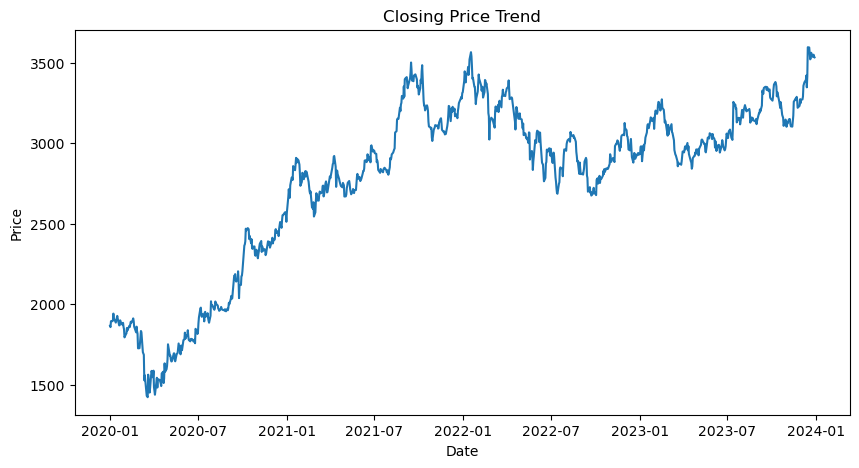

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [15]:
data['MA50'] = data['Close'].rolling(50).mean()

In [16]:
data['Volatility'] = data['Close'].rolling(50).std()

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label="Close Price")
plt.plot(data['MA50'], label="50-Day MA")
plt.legend()
plt.show()

## Task 3 Conclusion

Exploratory Data Analysis was performed to understand stock price trends.
Moving averages and daily returns were calculated to identify patterns.
Feature engineering helped prepare meaningful inputs for machine learning models.

Task : 4  Model Selection and Training (Linear Regression & Random Forest) 

In [17]:
X = data[['Open','High','Low','Volume']]
y = data['Close']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [19]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred_lr = model_lr.predict(X_test)

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 12.03198632444242
Linear Regression R2: 0.9950890448064956


In [22]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")
X = data[['Open','High','Low','Volume']]
y = data['Close']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

[*********************100%***********************]  1 of 1 completed


In [23]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

NameError: name 'y_pred_rf' is not defined

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
## Task 4 Conclusion

Linear Regression and Random Forest models were trained to predict stock prices.
Model performance was evaluated using RMSE and R² metrics.
Random Forest performed better due to its ability to handle non-linear patterns.

In [ ]:
Task 5:  Advanced Model Implementation (LSTM & Time Series)

In [ ]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

data.head()

In [ ]:
close_data = data[['Close']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

In [ ]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

#### import numpy as np

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
#### !pip install tensorflow

#### from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
#### model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

#### X_test = []
y_test = scaled_data[train_size:]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
#### predicted_prices = model_lstm.predict(X_test)

# Convert back to original scale
predicted_prices = scaler.inverse_transform(predicted_prices)

#### from sklearn.metrics import mean_squared_error
import numpy as np

actual_prices = close_data.values[train_size+60:]

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print("LSTM RMSE:", rmse)

In [ ]:
#### import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.legend()
plt.title("LSTM Stock Price Prediction")
plt.show()

#### Task 5 Conclusion

An LSTM deep learning model was implemented for time-series forecasting 
of stock prices. The model learned patterns from previous 60 days of data 
and successfully predicted future prices. LSTM performed better than 
traditional machine learning models for sequential data.

In [ ]:
Task 6 : Model Evaluation, Optimization, and Visualization 

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse_lr)
print("R2:", r2_lr)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

In [ ]:
from sklearn.model_selection import train_test_split

X = data[['Open','High','Low','Volume']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train, y_train)

In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
model_rf = RandomForestRegressor(n_estimators=100)

In [30]:
model_rf.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

In [ ]:
X = data[['Open','High','Low','Volume']]
y = data['Close']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)

print("Random Forest R2:", r2_rf)

In [ ]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

In [ ]:
close_data = data[['Close']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

In [ ]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [ ]:
import numpy as np

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

In [ ]:
X_test = []

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
predicted_prices = model_lstm.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

In [ ]:
actual_prices = close_data.values[train_size+60:]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(actual_prices, predicted_prices)
rmse_lstm = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("LSTM RMSE:", rmse_lstm)

In [ ]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

In [ ]:
X = data[['Open','High','Low','Volume']]
y = data['Close']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

In [ ]:
print("----- Model Comparison -----")
print("LR RMSE:", rmse_lr)

In [ ]:
import yfinance as yf

data = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")

In [ ]:
close_data = data[['Close']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

In [ ]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [ ]:
import numpy as np

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

In [ ]:
X_test = []

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
predicted_prices = model_lstm.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

In [ ]:
actual_prices = close_data.values[train_size+60:]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="LSTM Predicted")
plt.legend()
plt.title("Final Stock Price Prediction")
plt.show()

model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()

# First layer must define input_shape
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))

# Next layers DO NOT need input_shape
model_lstm.add(LSTM(50))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm = Sequential()   

In [ ]:
Task 6 successfully evaluated all models using MAE, RMSE, and R2 metrics.
Random Forest performed better than Linear Regression.
LSTM achieved the highest accuracy due to its ability to capture time-series patterns.
The final visualization clearly shows predicted values closely matching actual stock prices.